In [9]:
# Carregamento dos dados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("youtube_emojis_olid-br_normalizado.csv")
df.head(20)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm
0,😏,1,0,1,0.000225,0.000000
1,🎶,2,0,2,0.000449,0.000000
2,🐂,1,0,1,0.000225,0.000000
3,💃,1,0,1,0.000225,0.000000
4,💫,1,0,1,0.000225,0.000000
5,👈,1,1,2,0.000225,0.001312
6,🤤,5,0,5,0.001123,0.000000
7,🔞,1,0,1,0.000225,0.000000
8,✌,6,2,8,0.001348,0.002625
9,🌳,1,0,1,0.000225,0.000000


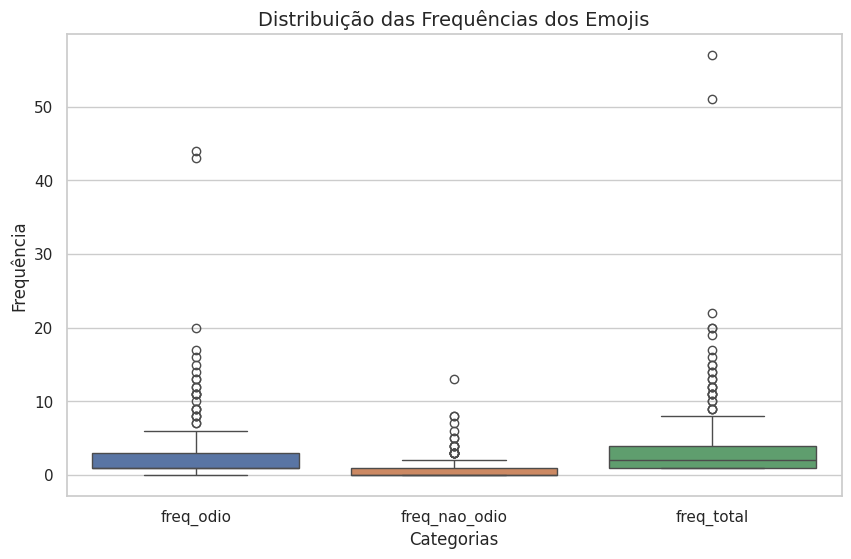

In [10]:
# Selecionar colunas de frequência
dados_boxplot = df[[
    "freq_odio",
    "freq_nao_odio",
    "freq_total"
]]

# Estilo
sns.set(style="whitegrid")

# Criar figura
plt.figure(figsize=(10, 6))

# Boxplot
sns.boxplot(data=dados_boxplot)

# Título e labels
plt.title("Distribuição das Frequências dos Emojis", fontsize=14)
plt.ylabel("Frequência")
plt.xlabel("Categorias")

# Mostrar gráfico
plt.show()

In [11]:
# Quais emojis são mais usados no YouTube, independentemente de ódio?
df.sort_values("freq_total", ascending=False).head(15)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm
176,😂,44,13,57,0.009883,0.017060
48,🤣,43,8,51,0.009659,0.010499
128,❤,14,8,22,0.003145,0.010499
24,😡,17,3,20,0.003819,0.003937
31,🤮,20,0,20,0.004492,0.000000
166,🤦,16,3,19,0.003594,0.003937
185,🏻,13,4,17,0.002920,0.005249
19,🤬,15,1,16,0.003369,0.001312
25,👏,8,7,15,0.001797,0.009186
53,🏼,12,3,15,0.002695,0.003937


In [12]:
# Quais emojis são mais usados no YouTube em discurso de ódio?
df.sort_values("freq_odio", ascending=False).head(15)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm
176,😂,44,13,57,0.009883,0.017060
48,🤣,43,8,51,0.009659,0.010499
31,🤮,20,0,20,0.004492,0.000000
24,😡,17,3,20,0.003819,0.003937
166,🤦,16,3,19,0.003594,0.003937
19,🤬,15,1,16,0.003369,0.001312
128,❤,14,8,22,0.003145,0.010499
23,🤢,13,0,13,0.002920,0.000000
185,🏻,13,4,17,0.002920,0.005249
53,🏼,12,3,15,0.002695,0.003937


In [13]:
# Quais emojis são mais usados no YouTube em discurso de não ódio?
df.sort_values("freq_nao_odio", ascending=False).head(15)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm
176,😂,44,13,57,0.009883,0.017060
48,🤣,43,8,51,0.009659,0.010499
128,❤,14,8,22,0.003145,0.010499
25,👏,8,7,15,0.001797,0.009186
76,🥰,6,6,12,0.001348,0.007874
123,🙏,5,5,10,0.001123,0.006562
161,👍,6,5,11,0.001348,0.006562
146,🤷,3,4,7,0.000674,0.005249
145,🏾,4,4,8,0.000898,0.005249
84,♂,8,4,12,0.001797,0.005249


In [14]:
# Produção da razão ódio/não ódio no YouTube.

# Evitar divisão por zero
df_analise = df[(df["freq_odio_norm"] > 0) & (df["freq_nao_odio_norm"] > 0)]

df_analise["razao_odio_nao_odio"] = (
    df_analise["freq_odio_norm"] / df_analise["freq_nao_odio_norm"]
)

# Quais emojis possuem maior razão ódio/não ódio no Instagram?
df_analise.sort_values("razao_odio_nao_odio", ascending=False).head(20)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm,razao_odio_nao_odio
19,🤬,15,1,16,0.003369,0.001312,2.567385
66,🙄,11,1,12,0.002471,0.001312,1.882749
129,🏽,10,1,11,0.002246,0.001312,1.711590
182,😅,9,1,10,0.002022,0.001312,1.540431
68,😭,12,2,14,0.002695,0.002625,1.026954
24,😡,17,3,20,0.003819,0.003937,0.969901
152,🤡,11,2,13,0.002471,0.002625,0.941375
48,🤣,43,8,51,0.009659,0.010499,0.919980
166,🤦,16,3,19,0.003594,0.003937,0.912848
57,😍,9,2,11,0.002022,0.002625,0.770216


In [15]:
# Quais emojis são muito mais usados em ódio?
df_analise[df_analise["razao_odio_nao_odio"] > 2].sort_values(
    "razao_odio_nao_odio", ascending=False
).head(10)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm,razao_odio_nao_odio
19,🤬,15,1,16,0.003369,0.001312,2.567385


In [16]:
# Quais emojis são muito mais usados em não ódio?
df_analise[df_analise["razao_odio_nao_odio"] < 0.5].sort_values(
    "razao_odio_nao_odio"
).head(10)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm,razao_odio_nao_odio
121,🏿,1,3,4,0.000225,0.003937,0.057053
136,🤨,1,2,3,0.000225,0.002625,0.085580
160,😪,1,2,3,0.000225,0.002625,0.085580
146,🤷,3,4,7,0.000674,0.005249,0.128369
5,👈,1,1,2,0.000225,0.001312,0.171159
11,♥,1,1,2,0.000225,0.001312,0.171159
80,😹,1,1,2,0.000225,0.001312,0.171159
58,😻,1,1,2,0.000225,0.001312,0.171159
120,😨,1,1,2,0.000225,0.001312,0.171159
126,😫,1,1,2,0.000225,0.001312,0.171159


In [17]:
# Muito mais em não ódio
df_analise[df_analise["razao_odio_nao_odio"] < 0.5].sort_values(
    "razao_odio_nao_odio"
).head(10)

,emoji,freq_odio,freq_nao_odio,freq_total,freq_odio_norm,freq_nao_odio_norm,razao_odio_nao_odio
121,🏿,1,3,4,0.000225,0.003937,0.057053
136,🤨,1,2,3,0.000225,0.002625,0.085580
160,😪,1,2,3,0.000225,0.002625,0.085580
146,🤷,3,4,7,0.000674,0.005249,0.128369
5,👈,1,1,2,0.000225,0.001312,0.171159
11,♥,1,1,2,0.000225,0.001312,0.171159
80,😹,1,1,2,0.000225,0.001312,0.171159
58,😻,1,1,2,0.000225,0.001312,0.171159
120,😨,1,1,2,0.000225,0.001312,0.171159
126,😫,1,1,2,0.000225,0.001312,0.171159


In [18]:
df_analise.to_csv(
    "etapa1_youtube_emojis.csv",
    index=False,
    encoding="utf-8"
)